# Machine Translation: English → Russian Seq2Seq Model
### Encoder-Decoder LSTM Architecture with Teacher Forcing
> Built with PyTorch. Dataset: English-Russian sentence pairs (rus.txt)

## 1. Install & Import Dependencies

In [1]:
import os, re, time, random, math
import unicodedata
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Hyperparameters

In [2]:
# ── Model hyperparameters (as specified in assignment) ────────────────────────
EMBED_DIM        = 256
HIDDEN_DIM       = 1024
NUM_LAYERS       = 2
DROPOUT          = 0.3
LEARNING_RATE    = 1e-3
BATCH_SIZE       = 128
NUM_EPOCHS       = 15
CLIP             = 1.0      # gradient clipping threshold
TEACHER_FORCING  = 0.5      # 50% chance of using ground-truth token as next input
MAX_VOCAB_SIZE   = 15_000   # keep top-N words per language
MAX_LEN          = 30       # max sentence length (tokens)
VAL_SPLIT        = 0.1      # 10% for validation
MAX_PAIRS        = 50_000   # limit dataset size for faster training (set None for all)

# Special token strings and indices
PAD_TOKEN = '<pad>'; PAD_IDX = 0
SOS_TOKEN = '<sos>'; SOS_IDX = 1
EOS_TOKEN = '<eos>'; EOS_IDX = 2
UNK_TOKEN = '<unk>'; UNK_IDX = 3

print('Hyperparameters set.')

Hyperparameters set.


## 3. Data Preprocessing
Load `rus.txt`, clean text, build vocabularies for English and Russian.

In [3]:
def unicode_to_ascii(s):
    """Convert unicode string to plain ASCII (handles accented chars)."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def clean_text(text, is_russian=False):
    """Lowercase, remove punctuation/numbers, normalize whitespace."""
    if not is_russian:
        text = unicode_to_ascii(text.lower())
    else:
        text = text.lower()
    text = re.sub(r"[^а-яёa-z\s]", ' ', text)   # keep only letters + spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_pairs(filepath, max_pairs=None, max_len=MAX_LEN):
    """Load tab-separated English-Russian pairs from file."""
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            eng = clean_text(parts[0], is_russian=False)
            rus = clean_text(parts[1], is_russian=True)
            # Filter very short or very long sentences
            if 2 <= len(eng.split()) <= max_len and 2 <= len(rus.split()) <= max_len:
                pairs.append((eng, rus))
            if max_pairs and len(pairs) >= max_pairs:
                break
    return pairs

# ── Load dataset ─────────────────────────────────────────────────────────────
DATA_PATH = 'rus.txt'   # make sure this file is in the same folder as the notebook
pairs = load_pairs(DATA_PATH, max_pairs=MAX_PAIRS)

random.shuffle(pairs)
print(f'Total valid pairs: {len(pairs):,}')
print('Sample pairs:')
for eng, rus in pairs[:5]:
    print(f'  EN: {eng}')
    print(f'  RU: {rus}')
    print()

Total valid pairs: 50,000
Sample pairs:
  EN: i m surprised
  RU: я изумлена

  EN: don t repeat that
  RU: не повторяйте это

  EN: i figured it out
  RU: я с этим разобрался

  EN: i didn t hear you
  RU: я тебя не слышал

  EN: tom is rich now
  RU: том теперь богат



## 4. Vocabulary Builder

In [4]:
class Vocabulary:
    """Word ↔ index mapping with special tokens."""
    def __init__(self, name, max_size=MAX_VOCAB_SIZE):
        self.name     = name
        self.max_size = max_size
        # Initialize with special tokens at fixed indices
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN}

    def build(self, sentences):
        """Build vocabulary from list of tokenized sentences."""
        counter = Counter(w for sent in sentences for w in sent.split())
        # Keep top (max_size - 4) words (4 reserved for special tokens)
        most_common = counter.most_common(self.max_size - 4)
        for word, _ in most_common:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f'{self.name} vocab size: {len(self.word2idx):,}')

    def encode(self, sentence):
        """Convert sentence string to list of indices."""
        return [self.word2idx.get(w, UNK_IDX) for w in sentence.split()]

    def decode(self, indices):
        """Convert list of indices back to string."""
        words = []
        for i in indices:
            w = self.idx2word.get(i, UNK_TOKEN)
            if w in (EOS_TOKEN, PAD_TOKEN): break
            if w != SOS_TOKEN:
                words.append(w)
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)


# Build vocabularies from training data
eng_sentences = [p[0] for p in pairs]
rus_sentences = [p[1] for p in pairs]

eng_vocab = Vocabulary('English')
rus_vocab = Vocabulary('Russian')
eng_vocab.build(eng_sentences)
rus_vocab.build(rus_sentences)

English vocab size: 4,796
Russian vocab size: 13,449


## 5. Dataset & DataLoaders

In [5]:
class TranslationDataset(Dataset):
    """
    Converts (English, Russian) string pairs into index tensors.
    Russian target tensors include <sos> at start and <eos> at end.
    """
    def __init__(self, pairs, eng_vocab, rus_vocab):
        self.pairs     = pairs
        self.eng_vocab = eng_vocab
        self.rus_vocab = rus_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng, rus = self.pairs[idx]
        src = torch.tensor(self.eng_vocab.encode(eng), dtype=torch.long)
        trg = torch.tensor(
            [SOS_IDX] + self.rus_vocab.encode(rus) + [EOS_IDX],
            dtype=torch.long
        )
        return src, trg


def collate_fn(batch):
    """Pad variable-length sequences to the same length within a batch."""
    src_batch, trg_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, trg_padded


# Train / validation split
val_size   = int(len(pairs) * VAL_SPLIT)
train_pairs = pairs[val_size:]
val_pairs   = pairs[:val_size]

train_dataset = TranslationDataset(train_pairs, eng_vocab, rus_vocab)
val_dataset   = TranslationDataset(val_pairs,   eng_vocab, rus_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f'Train pairs : {len(train_dataset):,}')
print(f'Val   pairs : {len(val_dataset):,}')
print(f'Train batches: {len(train_loader)}')

Train pairs : 45,000
Val   pairs : 5,000
Train batches: 352


## 6. Model Architecture — Encoder, Decoder, Seq2Seq

**Encoder** reads the English sentence and produces a context vector (final hidden + cell states).  
**Decoder** takes the context vector and generates Russian tokens one at a time.  
**Teacher Forcing**: during training, with probability `TEACHER_FORCING` the decoder receives the *ground-truth* previous token instead of its own prediction — this speeds up convergence.

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))    # (batch, src_len, embed_dim)
        _, (hidden, cell) = self.lstm(embedded)         # hidden/cell: (num_layers, batch, hidden_dim)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc        = nn.Linear(hidden_dim, vocab_size)   # project to vocab
        self.dropout   = nn.Dropout(dropout)

    def forward(self, trg_token, hidden, cell):
        # trg_token: (batch,) — single token index
        trg_token = trg_token.unsqueeze(1)                          # (batch, 1)
        embedded  = self.dropout(self.embedding(trg_token))         # (batch, 1, embed_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell)) # (batch, 1, hidden_dim)
        prediction = self.fc(output.squeeze(1))                      # (batch, vocab_size)
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=TEACHER_FORCING):
        # src: (batch, src_len)  |  trg: (batch, trg_len)
        batch_size = src.shape[0]
        trg_len    = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features

        # Tensor to store decoder outputs at each step
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(src.device)

        # Encode the source sentence
        hidden, cell = self.encoder(src)

        # First decoder input is always <sos>
        dec_input = trg[:, 0]   # (batch,)

        for t in range(1, trg_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t, :] = pred

            # Teacher forcing: use ground-truth or model's best guess
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input   = trg[:, t] if use_teacher else pred.argmax(dim=1)

        return outputs   # (batch, trg_len, vocab_size)


# ── Instantiate ───────────────────────────────────────────────────────────────
encoder = Encoder(len(eng_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(len(rus_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)

# Xavier uniform weight initialization (improves convergence)
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(f'Encoder vocab: {len(eng_vocab):,}  |  Decoder vocab: {len(rus_vocab):,}')

Model parameters: 45,751,689
Encoder vocab: 4,796  |  Decoder vocab: 13,449


## 7. Training & Evaluation Functions

In [7]:
# CrossEntropyLoss — ignore padding tokens so they don't affect the loss
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


def train_epoch(model, loader, optimizer, criterion, clip):
    """One full training pass. Returns average loss."""
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio=TEACHER_FORCING)
        # output: (batch, trg_len, vocab_size)
        # Reshape: skip first token (<sos>) for both output and target
        output = output[:, 1:, :].reshape(-1, output.shape[-1])  # (batch*(trg_len-1), vocab)
        trg    = trg[:, 1:].reshape(-1)                           # (batch*(trg_len-1),)

        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)   # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, criterion):
    """Evaluation without teacher forcing. Returns average loss."""
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model(src, trg, teacher_forcing_ratio=0.0)  # no teacher forcing
            output = output[:, 1:, :].reshape(-1, output.shape[-1])
            trg    = trg[:, 1:].reshape(-1)
            epoch_loss += criterion(output, trg).item()

    return epoch_loss / len(loader)


print('Criterion, optimizer, scheduler defined.')

Criterion, optimizer, scheduler defined.


## 8. Training Loop — Save Best Model

In [8]:
BEST_MODEL_PATH = 'seq2seq_best.pt'
best_val_loss   = float('inf')
train_losses, val_losses = [], []

print(f'Training for {NUM_EPOCHS} epochs...')
print(f'Teacher forcing ratio: {TEACHER_FORCING}')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss  = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    val_loss = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    # Perplexity = e^loss (standard MT metric)
    tr_ppl  = math.exp(tr_loss)
    val_ppl = math.exp(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = '✓ saved'
    else:
        saved = ''

    elapsed = time.time() - t0
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.3f} (PPL {tr_ppl:6.1f}) | '
          f'Val Loss: {val_loss:.3f} (PPL {val_ppl:6.1f}) | '
          f'{elapsed:.1f}s  {saved}')

print('='*65)
print(f'Best validation loss: {best_val_loss:.4f}  (PPL {math.exp(best_val_loss):.2f})')

Training for 15 epochs...
Teacher forcing ratio: 0.5
Epoch  1/15 | Train Loss: 4.673 (PPL  107.0) | Val Loss: 4.023 (PPL   55.9) | 27.2s  ✓ saved
Epoch  2/15 | Train Loss: 3.437 (PPL   31.1) | Val Loss: 3.284 (PPL   26.7) | 26.7s  ✓ saved
Epoch  3/15 | Train Loss: 2.623 (PPL   13.8) | Val Loss: 2.844 (PPL   17.2) | 26.6s  ✓ saved
Epoch  4/15 | Train Loss: 2.023 (PPL    7.6) | Val Loss: 2.619 (PPL   13.7) | 26.7s  ✓ saved
Epoch  5/15 | Train Loss: 1.596 (PPL    4.9) | Val Loss: 2.461 (PPL   11.7) | 26.6s  ✓ saved
Epoch  6/15 | Train Loss: 1.300 (PPL    3.7) | Val Loss: 2.418 (PPL   11.2) | 26.3s  ✓ saved
Epoch  7/15 | Train Loss: 1.090 (PPL    3.0) | Val Loss: 2.393 (PPL   10.9) | 26.0s  ✓ saved
Epoch  8/15 | Train Loss: 0.947 (PPL    2.6) | Val Loss: 2.397 (PPL   11.0) | 25.8s  
Epoch  9/15 | Train Loss: 0.856 (PPL    2.4) | Val Loss: 2.403 (PPL   11.1) | 25.8s  
Epoch 10/15 | Train Loss: 0.783 (PPL    2.2) | Val Loss: 2.431 (PPL   11.4) | 25.9s  
Epoch 11/15 | Train Loss: 0.599 (PPL  

## 9. Training Curves — Loss & Perplexity

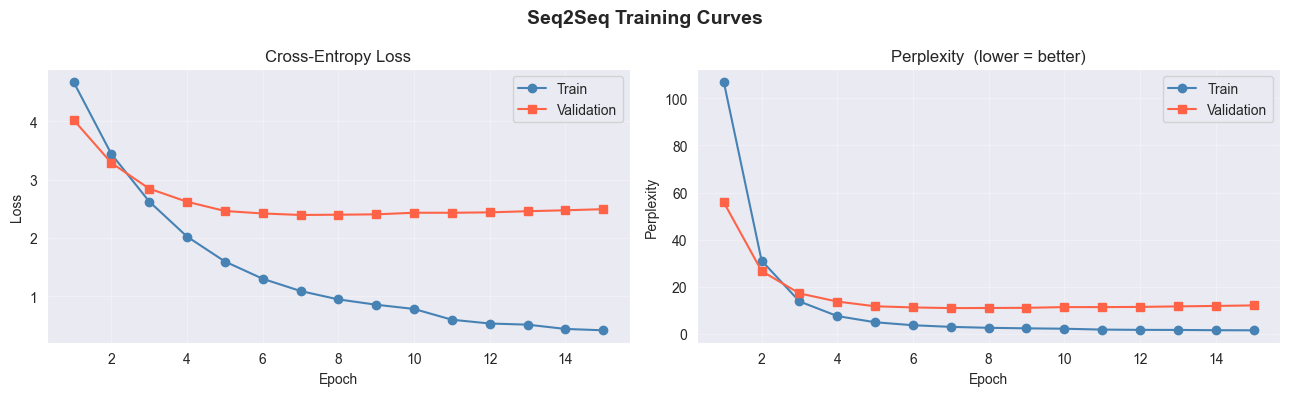

In [9]:
epochs = range(1, NUM_EPOCHS + 1)
train_ppl = [math.exp(l) for l in train_losses]
val_ppl   = [math.exp(l) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Seq2Seq Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, train_losses, '-o', color='steelblue', label='Train')
axes[0].plot(epochs, val_losses,   '-s', color='tomato',    label='Validation')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Perplexity
axes[1].plot(epochs, train_ppl, '-o', color='steelblue', label='Train')
axes[1].plot(epochs, val_ppl,   '-s', color='tomato',    label='Validation')
axes[1].set_title('Perplexity  (lower = better)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Translation Function

In [10]:
def translate(sentence, model, eng_vocab, rus_vocab, max_len=50):
    """
    Translate an English sentence to Russian.
    Accepts either a string or a pre-encoded tensor.
    """
    model.eval()

    # Encode source
    if isinstance(sentence, str):
        sentence = clean_text(sentence, is_russian=False)
        src_indices = eng_vocab.encode(sentence)
        src_tensor  = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(DEVICE)
    else:
        src_tensor = sentence.to(DEVICE)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    # Generate tokens one at a time
    dec_input   = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)
    translation = []

    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell = model.decoder(dec_input, hidden, cell)
            best_token = pred.argmax(dim=1).item()

            if best_token == EOS_IDX:
                break

            if best_token not in (PAD_IDX, SOS_IDX):
                translation.append(rus_vocab.idx2word.get(best_token, UNK_TOKEN))

            dec_input = torch.tensor([best_token], dtype=torch.long).to(DEVICE)

    return ' '.join(translation)


# ── Load best saved model before translating ─────────────────────────────────
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print('Best model loaded.')

Best model loaded.


## 11. Sample Translations

In [11]:
# ── Show translations on validation samples ───────────────────────────────────
print(f"{'='*65}")
print(f"  {'ENGLISH':<28}  {'REFERENCE (RU)':<20}  PREDICTED")
print(f"{'='*65}")

sample_pairs = random.sample(val_pairs, min(10, len(val_pairs)))

for eng, rus in sample_pairs:
    pred = translate(eng, model, eng_vocab, rus_vocab)
    print(f"  EN : {eng}")
    print(f"  REF: {rus}")
    print(f"  OUT: {pred}")
    print()

# ── Try custom sentences ──────────────────────────────────────────────────────
custom = [
    "hello how are you",
    "i love learning languages",
    "the weather is nice today",
]
print('Custom translations:')
for sent in custom:
    print(f'  EN: {sent}')
    print(f'  RU: {translate(sent, model, eng_vocab, rus_vocab)}')
    print()

  ENGLISH                       REFERENCE (RU)        PREDICTED
  EN : did anyone miss me
  REF: по мне кто нибудь скучал
  OUT: меня нибудь нибудь не сказал

  EN : tom is hungry
  REF: том хочет есть
  OUT: том хочет есть

  EN : i stopped laughing
  REF: я перестал смеяться
  OUT: я перестала плакать

  EN : the light is out
  REF: свет потушен
  OUT: свет погашен

  EN : you re a sexist
  REF: ты сексист
  OUT: ты фантазёр

  EN : i need to tell tom
  REF: мне нужно сказать тому
  OUT: мне нужно рассказать тому

  EN : we re ok
  REF: мы в порядке
  OUT: у нас всё нормально

  EN : we got robbed
  REF: нас ограбили
  OUT: нас приехали

  EN : this is our bag
  REF: это наша сумка
  OUT: это моя сумка

  EN : deal with it
  REF: разбирайся с этим
  OUT: разберитесь с этим

Custom translations:
  EN: hello how are you
  RU: привет как дела

  EN: i love learning languages
  RU: я обожаю гамбургеры

  EN: the weather is nice today
  RU: кровать немного



## 12. Final Summary

In [12]:
best_epoch = val_losses.index(min(val_losses)) + 1

print('='*55)
print('           FINAL SUMMARY')
print('='*55)
print(f'  Architecture    : Encoder-Decoder LSTM (Seq2Seq)')
print(f'  Embed dim       : {EMBED_DIM}   |  Hidden dim: {HIDDEN_DIM}')
print(f'  LSTM layers     : {NUM_LAYERS}   |  Dropout:    {DROPOUT}')
print(f'  Teacher forcing : {TEACHER_FORCING}')
print(f'  Dataset pairs   : {len(pairs):,}')
print(f'  English vocab   : {len(eng_vocab):,}')
print(f'  Russian vocab   : {len(rus_vocab):,}')
print(f'  Best epoch      : {best_epoch}')
print(f'  Best val loss   : {best_val_loss:.4f}')
print(f'  Best val PPL    : {math.exp(best_val_loss):.2f}')
print('='*55)

           FINAL SUMMARY
  Architecture    : Encoder-Decoder LSTM (Seq2Seq)
  Embed dim       : 256   |  Hidden dim: 1024
  LSTM layers     : 2   |  Dropout:    0.3
  Teacher forcing : 0.5
  Dataset pairs   : 50,000
  English vocab   : 4,796
  Russian vocab   : 13,449
  Best epoch      : 7
  Best val loss   : 2.3928
  Best val PPL    : 10.94
